In [1]:
import pandas as pd

df = pd.read_csv('/workspaces/Machine-Learning-with-Python/StreamLit/startup_funding.csv')
df.columns

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='str')

In [2]:
df['Startup Name'].unique().tolist()

['BYJU’S',
 'Shuttl',
 'Mamaearth',
 'https://www.wealthbucket.in/',
 'Fashor',
 'Pando',
 'Zomato',
 'Ecozen',
 'CarDekho',
 'Dhruva Space',
 'Rivigo',
 'Healthians',
 'Licious',
 'InCred',
 'Trell',
 'Rein Games',
 'Lenskart.com',
 'Freshworks',
 'Misters',
 'Sunstone Eduversity Pvt. Ltd',
 'Burger Singh',
 'Ninjacart',
 'Aye Finance',
 'SuperGaming',
 'Clumio',
 'eBikeGo',
 'Digital Mall Asia',
 'Medikabazaar',
 'Vogo Automotive',
 'Furtados School of Music',
 'Paytm',
 'Dunzo',
 'Udaan',
 'The Man Company',
 'FPL Technologies',
 'Cashflo',
 'Digital F5',
 '3rdFlix',
 '75F',
 'Myelin Foundry',
 'Atomberg Technology',
 'GOQii',
 'Vyapar App',
 'Progcap',
 'MyPetrolPump',
 'Alteria Capital',
 'Pine Labs',
 'Meesho',
 'Cars24',
 'Uniphore',
 'Zendrive',
 'Lo! Foods',
 'Tala',
 'INDwealth',
 'HungerBox',
 'AdmitKard',
 'Mishry Reviews',
 'Grofers',
 'Rapido Bike Taxi',
 'RenewBuy',
 'Atlan',
 'WizCounsel',
 'Ola Cabs',
 'Daalchini Technologies',
 '"BYJU\\\\\'S"',
 'Moglix',
 'Ezyhaul',


In [3]:
sorted(df['Investors Name'].fillna('Unknown').unique().tolist())

['"Kedaraa Capital, Ontario Teachers\\\\\'"',
 '021 Capita, Binny Bansal',
 '1Crowd',
 '1Crowd (through crowd funding)',
 '1Crowd (through crowdfunding)',
 '1Crowd, Ankur Capital',
 '1Crowd, Eureka Forbes Ltd, Shapoorji Pallonji & Co. Ltd.',
 '3 undisclosed HNIs',
 '3 undisclosed investors',
 '3One4 Capital',
 '3one4 Capital, Mumbai Angels, Aarin Capital',
 '3one4 Capital, Tracxn Labs, Aaruha Technology Fund, Endiya Partners',
 '3one4 capital',
 '500 Startups',
 '500 Startups, IDG Ventures & Advantedge fund, Neeraj Arora, Leon Seynave',
 '500 Startups, IvyCap Ventures',
 '500 Startups, Littlerock, Singularity Ventures',
 '500 Startups, Mato Peric & Others',
 '500 Startups, Mato Peric, TracxnLabs',
 '500 Startups, Purvi Capital, Rajan Anandan, Abhishek Gupta',
 '500 Startups, Smile Multimedia, Kunal Bahl, Rohit Bansal, Girish Matrubootham',
 '500 Startups, TV Mohandas Pai, Tandem Capital, Vikram Chachra, Aloke Bajpai',
 '50K Ventures',
 '50k Ventures, Munish Jauhar, Pulkit Jain, Rohit N

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Sr No              3044 non-null   int64
 1   Date dd/mm/yyyy    3044 non-null   str  
 2   Startup Name       3044 non-null   str  
 3   Industry Vertical  2873 non-null   str  
 4   SubVertical        2108 non-null   str  
 5   City  Location     2864 non-null   str  
 6   Investors Name     3020 non-null   str  
 7   InvestmentnType    3040 non-null   str  
 8   Amount in USD      2084 non-null   str  
 9   Remarks            419 non-null    str  
dtypes: int64(1), str(9)
memory usage: 593.3 KB


In [5]:
df.drop(columns='Remarks', inplace=True)


In [6]:
df.set_index('Sr No', inplace=True)

In [7]:
df.rename(columns={
    'Date dd/mm/yyyy':'date',
    'Startup Name':'startup',
    'Industry Vertical':'vertical',
    'SubVertical':'subvertical',
    'City  Location':'city',
    'Investors Name':'investors',
    'Amount in USD':'amount',
    'InvestmentnType':'round',
}, inplace=True)

In [8]:
df['amount']=df['amount'].fillna('0')
df['amount'] = df['amount'].str.replace(',','')
df['amount'] = df['amount'].str.replace('Undisclosed','0')



In [9]:
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df['amount']


Sr No
1       200000000.0
2         8048394.0
3        18358860.0
4         3000000.0
5         1800000.0
           ...     
3040      4500000.0
3041       825000.0
3042      1500000.0
3043            0.0
3044       140000.0
Name: amount, Length: 3044, dtype: float64

In [10]:
def in_inr(dollar):
  inr = dollar*95
  return inr / 10000000

In [11]:
df['amount']=df['amount'].apply(in_inr)
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1900.000000
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,76.459743
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,174.409170
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,28.500000
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,17.100000


In [12]:
df['date']=df['date'].str.replace('05/072018','05/07/2018')
df['date']=pd.to_datetime(df['date'], errors='coerce')



In [13]:
df.columns

Index(['date', 'startup', 'vertical', 'subvertical', 'city', 'investors',
       'round', 'amount'],
      dtype='str')

In [14]:
df = df.dropna(subset=['date', 'startup', 'vertical','city', 'investors',
       'round', 'amount'])

df.info()

<class 'pandas.DataFrame'>
Index: 1202 entries, 1 to 2829
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1202 non-null   datetime64[us]
 1   startup      1202 non-null   str           
 2   vertical     1202 non-null   str           
 3   subvertical  890 non-null    str           
 4   city         1202 non-null   str           
 5   investors    1202 non-null   str           
 6   round        1202 non-null   str           
 7   amount       1202 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 208.3 KB


In [15]:
df.to_csv('startup_cleaned.csv', index=False)

In [16]:
data_inv = set(df['investors'].str.split(',').sum())

In [17]:
df[df['investors'].str.contains('IDG Ventures')].head()[['date', 'startup', 'vertical', 'city', 'round', 'amount']]

,date,startup,vertical,city,round,amount
Sr No,,,,,,
259,2018-02-05,Bizongo,Consumer Internet,Mumbai,Private Equity,209.00
439,2017-07-12,eShakti,Ecommerce,Chennai,Debt Funding,21.85
478,2017-04-11,Hevo Data,Technology,Bangalore,Private Equity,9.50
479,2017-06-11,Smart Karma,Technology,Bangalore,Private Equity,0.00
490,2017-09-11,Mobiliz AR,Technology,Bangalore,Private Equity,0.00


In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 1202 entries, 1 to 2829
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1202 non-null   datetime64[us]
 1   startup      1202 non-null   str           
 2   vertical     1202 non-null   str           
 3   subvertical  890 non-null    str           
 4   city         1202 non-null   str           
 5   investors    1202 non-null   str           
 6   round        1202 non-null   str           
 7   amount       1202 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 208.3 KB


In [21]:
df[df['investors'].str.contains('IDG Ventures')].groupby('startup')['amount'].sum().sort_values(ascending=False)

startup
Lenskart                 570.000
Bizongo                  237.500
Curefit                  142.500
Fintellix                142.500
Xpressbees               118.750
FirstCry.com              95.000
HealthifyMe               57.000
Blowhorn                  34.675
eShakti                   21.850
POPxo.com                 19.000
Uniphore                  19.000
Hansel.io                 12.825
Little Black Book          9.500
Cloudcherry Analytics      9.500
Hevo Data                  9.500
CityFlo                    7.125
Tripoto                    0.000
Smart Karma                0.000
Mobiliz AR                 0.000
Unbxd                      0.000
Name: amount, dtype: float64

<Axes: >

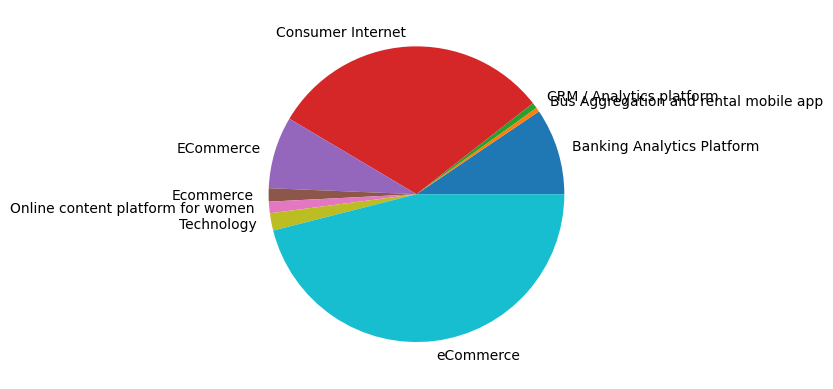

In [22]:
df[df['investors'].str.contains('IDG Ventures')].groupby('vertical')['amount'].sum().plot(kind='pie')

<Axes: >

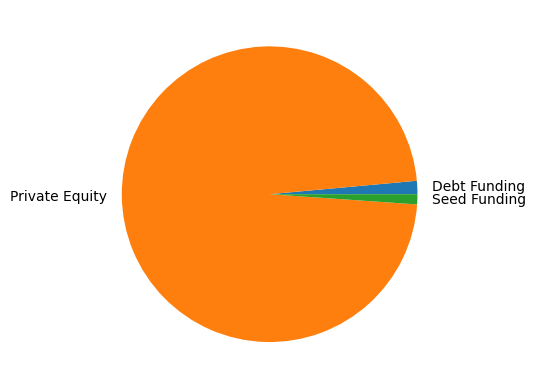

In [23]:
df[df['investors'].str.contains('IDG Ventures')].groupby('round')['amount'].sum().plot(kind='pie')

<Axes: >

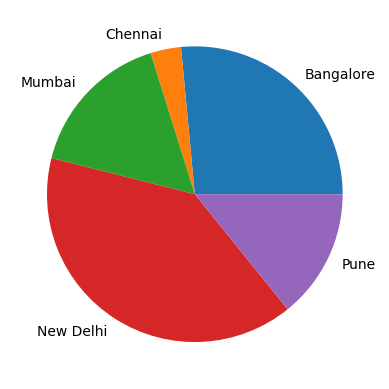

In [24]:
df[df['investors'].str.contains('IDG Ventures')].groupby('city')['amount'].sum().plot(kind='pie')

In [25]:
df['year'] = df['date'].dt.year

<Axes: xlabel='year'>

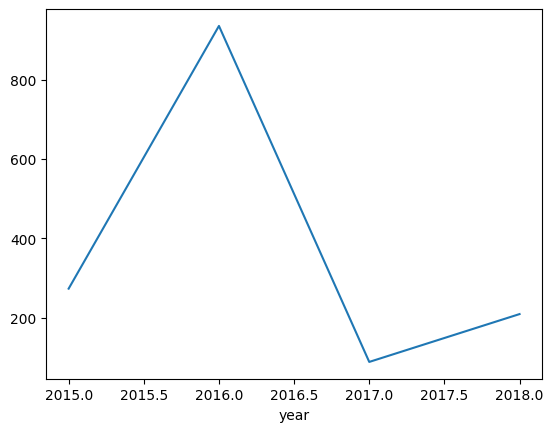

In [26]:
df[df['investors'].str.contains('IDG Ventures')].groupby('year')['amount'].sum().plot()